In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_rows', None)

In [2]:
data=pd.read_csv('../data/raw/bank.csv',sep=';')
#sep ; because data is seperated by ;

In [3]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


<h2>Basic Data reconnaissance</h2>

In [4]:
data.shape

(4521, 17)

In [5]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4521 non-null   str  
 2   marital    4521 non-null   str  
 3   education  4521 non-null   str  
 4   default    4521 non-null   str  
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   str  
 7   loan       4521 non-null   str  
 8   contact    4521 non-null   str  
 9   day        4521 non-null   int64
 10  month      4521 non-null   str  
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   4521 non-null   str  
 16  y          4521 non-null   str  
dtypes: int64(7), str(10)
memory usage: 600.6 KB


In [7]:
data.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data['y'].value_counts(normalize=True)*100

y
no     88.476001
yes    11.523999
Name: proportion, dtype: float64

<h2>Feature Understanding</h2>

In [10]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [11]:
numerical_columns=['age','balance','day','duration','campaign','pdays','previous']

In [12]:
categoryical_columns=['job','marital','education','default','housing','loan','contact','month','poutcome','y']

In [13]:
data['campaign'].describe()

count    4521.000000
mean        2.793630
std         3.109807
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        50.000000
Name: campaign, dtype: float64

<p>Campaign is number of contacts performed in this campaign for this client , higher campaign means higher number of calls made to retain client</p>

In [14]:
import matplotlib.pyplot as plt

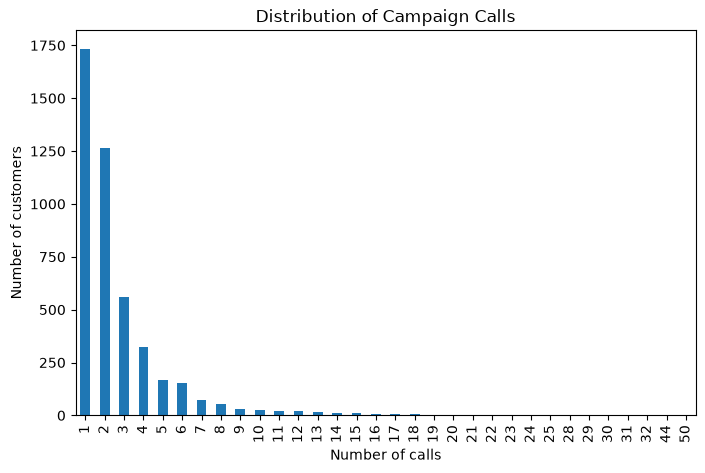

In [15]:
plt.figure(figsize=(8, 5))

data["campaign"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Number of calls")
plt.ylabel("Number of customers")
plt.title("Distribution of Campaign Calls")

plt.show()

In [16]:
data[numerical_columns].describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [17]:
data[numerical_columns].head()

,age,balance,day,duration,campaign,pdays,previous
0,30,1787,19,79,1,-1,0
1,33,4789,11,220,1,339,4
2,35,1350,16,185,1,330,1
3,30,1476,3,199,4,-1,0
4,59,0,5,226,1,-1,0


<h4>Understanding Numerical columns</h4>

In [18]:
data['age'].describe()

count    4521.000000
mean       41.170095
std        10.576211
min        19.000000
25%        33.000000
50%        39.000000
75%        49.000000
max        87.000000
Name: age, dtype: float64

In [19]:
data['balance'].describe()

count     4521.000000
mean      1422.657819
std       3009.638142
min      -3313.000000
25%         69.000000
50%        444.000000
75%       1480.000000
max      71188.000000
Name: balance, dtype: float64

In [20]:
data[data['balance']<0]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no
18,25,blue-collar,single,primary,no,-221,yes,no,unknown,23,may,250,1,-1,0,unknown,no
48,32,entrepreneur,single,primary,yes,-849,yes,yes,cellular,4,feb,204,1,-1,0,unknown,no
60,41,blue-collar,married,primary,no,-516,no,yes,telephone,8,jul,554,3,-1,0,unknown,no
92,27,services,single,secondary,no,-195,yes,no,cellular,18,may,391,1,-1,0,unknown,yes
123,36,blue-collar,married,secondary,no,-231,no,yes,cellular,15,jul,779,2,-1,0,unknown,no
124,51,management,single,tertiary,yes,-55,yes,no,cellular,11,may,281,2,266,6,failure,no
132,43,blue-collar,married,unknown,yes,-715,yes,no,unknown,30,may,67,3,-1,0,unknown,no
138,52,management,married,tertiary,no,-970,yes,no,cellular,4,feb,489,1,-1,0,unknown,yes
152,45,unemployed,divorced,primary,yes,-249,yes,yes,unknown,1,jul,92,1,-1,0,unknown,no


In [21]:
data['day'].describe()

count    4521.000000
mean       15.915284
std         8.247667
min         1.000000
25%         9.000000
50%        16.000000
75%        21.000000
max        31.000000
Name: day, dtype: float64

In [22]:
data['duration'].describe()

count    4521.000000
mean      263.961292
std       259.856633
min         4.000000
25%       104.000000
50%       185.000000
75%       329.000000
max      3025.000000
Name: duration, dtype: float64

In [23]:
data['pdays'].describe()

count    4521.000000
mean       39.766645
std       100.121124
min        -1.000000
25%        -1.000000
50%        -1.000000
75%        -1.000000
max       871.000000
Name: pdays, dtype: float64

In [24]:
data[(data['pdays']<=0) & (data['y']=='yes')]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
13,20,student,single,secondary,no,502,no,no,cellular,30,apr,261,1,-1,0,unknown,yes
30,68,retired,divorced,secondary,no,4189,no,no,telephone,14,jul,897,2,-1,0,unknown,yes
33,32,management,single,tertiary,no,2536,yes,no,cellular,26,aug,958,6,-1,0,unknown,yes
34,49,technician,married,tertiary,no,1235,no,no,cellular,13,aug,354,3,-1,0,unknown,yes
36,78,retired,divorced,primary,no,229,no,no,telephone,22,oct,97,1,-1,0,unknown,yes
37,32,blue-collar,married,secondary,no,2089,yes,no,cellular,14,nov,132,1,-1,0,unknown,yes
50,45,blue-collar,divorced,primary,no,844,no,no,unknown,5,jun,1018,3,-1,0,unknown,yes
80,27,admin.,divorced,secondary,no,451,yes,no,cellular,16,jul,652,1,-1,0,unknown,yes
84,37,management,married,tertiary,no,1315,no,no,cellular,30,jun,224,1,-1,0,unknown,yes
92,27,services,single,secondary,no,-195,yes,no,cellular,18,may,391,1,-1,0,unknown,yes


In [25]:
uncontacted = data[data['pdays'] <= 0]

uncontacted.groupby('poutcome')['y'].value_counts()

poutcome  y  
unknown   no     3368
          yes     337
Name: count, dtype: int64

In [26]:
data['previous'].describe()

count    4521.000000
mean        0.542579
std         1.693562
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        25.000000
Name: previous, dtype: float64

<h4>Understanding Categorical columns</h4>

In [27]:
data[categoryical_columns].head()

,job,marital,education,default,housing,loan,contact,month,poutcome,y
0,unemployed,married,primary,no,no,no,cellular,oct,unknown,no
1,services,married,secondary,no,yes,yes,cellular,may,failure,no
2,management,single,tertiary,no,yes,no,cellular,apr,failure,no
3,management,married,tertiary,no,yes,yes,unknown,jun,unknown,no
4,blue-collar,married,secondary,no,yes,no,unknown,may,unknown,no


In [28]:
data[categoryical_columns].nunique()


job          12
marital       3
education     4
default       2
housing       2
loan          2
contact       3
month        12
poutcome      4
y             2
dtype: int64

In [29]:
data['job'].unique()

<StringArray>
[   'unemployed',      'services',    'management',   'blue-collar',
 'self-employed',    'technician',  'entrepreneur',        'admin.',
       'student',     'housemaid',       'retired',       'unknown']
Length: 12, dtype: str

In [30]:
for cols in categoryical_columns:
    print(f'{cols} {data[cols].unique()}')

job <StringArray>
[   'unemployed',      'services',    'management',   'blue-collar',
 'self-employed',    'technician',  'entrepreneur',        'admin.',
       'student',     'housemaid',       'retired',       'unknown']
Length: 12, dtype: str
marital <StringArray>
['married', 'single', 'divorced']
Length: 3, dtype: str
education <StringArray>
['primary', 'secondary', 'tertiary', 'unknown']
Length: 4, dtype: str
default <StringArray>
['no', 'yes']
Length: 2, dtype: str
housing <StringArray>
['no', 'yes']
Length: 2, dtype: str
loan <StringArray>
['no', 'yes']
Length: 2, dtype: str
contact <StringArray>
['cellular', 'unknown', 'telephone']
Length: 3, dtype: str
month <StringArray>
['oct', 'may', 'apr', 'jun', 'feb', 'aug', 'jan', 'jul', 'nov', 'sep', 'mar',
 'dec']
Length: 12, dtype: str
poutcome <StringArray>
['unknown', 'failure', 'other', 'success']
Length: 4, dtype: str
y <StringArray>
['no', 'yes']
Length: 2, dtype: str


<h4>Investigating Values </h4>

In [31]:
# these columns have unknown values 
for col in categoryical_columns:
    if 'unknown' in data[col].unique():
        print(col)

job
education
contact
poutcome


In [32]:
unknown_job=data[data['job']=='unknown']

In [33]:
unknown_job['y'].value_counts()

y
no     31
yes     7
Name: count, dtype: int64

In [34]:
unknown_education=data[data['education']=='unknown']

In [35]:
unknown_education['y'].value_counts()

y
no     168
yes     19
Name: count, dtype: int64

In [36]:
data.groupby('contact')['y'].value_counts(normalize=True)*100

contact    y  
cellular   no     85.635359
           yes    14.364641
telephone  no     85.382060
           yes    14.617940
unknown    no     95.392749
           yes     4.607251
Name: proportion, dtype: float64

In [37]:
data.groupby('poutcome')['y'].value_counts(normalize=True)*100

poutcome  y  
failure   no     87.142857
          yes    12.857143
other     no     80.710660
          yes    19.289340
success   yes    64.341085
          no     35.658915
unknown   no     90.904184
          yes     9.095816
Name: proportion, dtype: float64

In [38]:
data[data['pdays']==-1]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
7,39,technician,married,secondary,no,147,yes,no,cellular,6,may,151,2,-1,0,unknown,no
8,41,entrepreneur,married,tertiary,no,221,yes,no,unknown,14,may,57,2,-1,0,unknown,no
10,39,services,married,secondary,no,9374,yes,no,unknown,20,may,273,1,-1,0,unknown,no
11,43,admin.,married,secondary,no,264,yes,no,cellular,17,apr,113,2,-1,0,unknown,no
12,36,technician,married,tertiary,no,1109,no,no,cellular,13,aug,328,2,-1,0,unknown,no
13,20,student,single,secondary,no,502,no,no,cellular,30,apr,261,1,-1,0,unknown,yes
15,40,management,married,tertiary,no,194,no,yes,cellular,29,aug,189,2,-1,0,unknown,no


In [39]:
neg_or_zero_balance=data[data['balance']<=0]

In [40]:
neg_or_zero_balance['y'].value_counts(normalize=True)

y
no     0.917012
yes    0.082988
Name: proportion, dtype: float64

In [41]:
neg_or_zero_balance

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no
18,25,blue-collar,single,primary,no,-221,yes,no,unknown,23,may,250,1,-1,0,unknown,no
20,38,management,divorced,unknown,no,0,yes,no,cellular,18,nov,96,2,-1,0,unknown,no
47,26,blue-collar,married,primary,no,0,yes,no,unknown,21,may,425,1,-1,0,unknown,no
48,32,entrepreneur,single,primary,yes,-849,yes,yes,cellular,4,feb,204,1,-1,0,unknown,no
60,41,blue-collar,married,primary,no,-516,no,yes,telephone,8,jul,554,3,-1,0,unknown,no
68,41,management,married,secondary,no,0,no,yes,cellular,7,jul,630,3,-1,0,unknown,no
70,37,management,married,tertiary,no,0,no,no,cellular,16,jul,268,2,182,3,success,yes
92,27,services,single,secondary,no,-195,yes,no,cellular,18,may,391,1,-1,0,unknown,yes


In [42]:
#neg or zero balance prob means overdraft

In [43]:
#unknown row per category

In [44]:
for col in categoryical_columns:
   if 'unknown' in data[col].values:
      print(f'{col} : {(data[col]=='unknown').sum()}')

job : 38
education : 187
contact : 1324
poutcome : 3705


In [45]:
poutcome_unknown=data[data['poutcome']=='unknown']

In [46]:
poutcome_unknown['pdays'].value_counts(normalize=True)

pdays
-1    1.0
Name: proportion, dtype: float64

<h3>Relationship EDA 💆‍♀️</h3>

In [47]:
#relationship between different jobs and outcome
data.groupby('job')['y'].value_counts()

job            y  
admin.         no     420
               yes     58
blue-collar    no     877
               yes     69
entrepreneur   no     153
               yes     15
housemaid      no      98
               yes     14
management     no     838
               yes    131
retired        no     176
               yes     54
self-employed  no     163
               yes     20
services       no     379
               yes     38
student        no      65
               yes     19
technician     no     685
               yes     83
unemployed     no     115
               yes     13
unknown        no      31
               yes      7
Name: count, dtype: int64

In [48]:
#relation between contact type and yes
data.groupby('contact')['y'].value_counts(normalize=True)*100

contact    y  
cellular   no     85.635359
           yes    14.364641
telephone  no     85.382060
           yes    14.617940
unknown    no     95.392749
           yes     4.607251
Name: proportion, dtype: float64

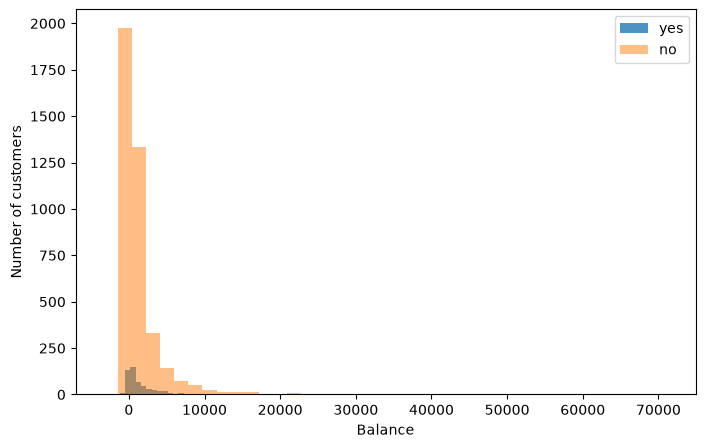

In [49]:
#spread of column balance
plt.figure(figsize=(8,5))
plt.hist(data[data['y']=='yes']['balance'],bins=40,alpha=0.8,label='yes')
plt.hist(data[data['y']=='no']['balance'],bins=40,alpha=0.5,label='no')
plt.xlabel('Balance')
plt.ylabel('Number of customers')
plt.legend()
plt.show()

<Figure size 800x500 with 0 Axes>

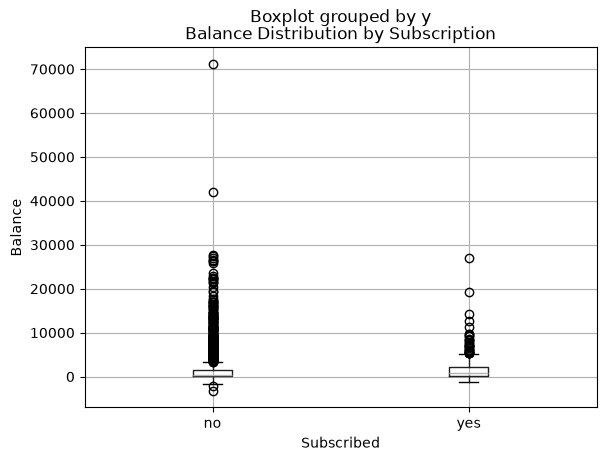

In [50]:
plt.figure(figsize=(8, 5))

data.boxplot(column='balance', by='y')

plt.xlabel('Subscribed')
plt.ylabel('Balance')
plt.title('Balance Distribution by Subscription')

plt.show()

In [51]:
#creating balance bins
data['balance'].describe()

count     4521.000000
mean      1422.657819
std       3009.638142
min      -3313.000000
25%         69.000000
50%        444.000000
75%       1480.000000
max      71188.000000
Name: balance, dtype: float64

In [52]:
balance_bin=[-3313,0,69,444,1480,71188]
balance_label=['negative/zero','low','medium','high','very-high']
data['balance_group']=pd.cut(data['balance'],bins=balance_bin,labels=balance_label,include_lowest=True)

In [53]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,balance_group
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no,very-high
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no,very-high
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no,high
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no,high
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no,negative/zero


In [54]:
data.groupby('balance_group')['y'].value_counts(normalize=100)*100

balance_group  y  
negative/zero  no     91.701245
               yes     8.298755
low            no     91.707317
               yes     8.292683
medium         no     90.602837
               yes     9.397163
high           no     86.825818
               yes    13.174182
very-high      no     84.765279
               yes    15.234721
Name: proportion, dtype: float64

In [55]:
#poutcome vs y
data.groupby('poutcome')['y'].value_counts(normalize=True)*100

poutcome  y  
failure   no     87.142857
          yes    12.857143
other     no     80.710660
          yes    19.289340
success   yes    64.341085
          no     35.658915
unknown   no     90.904184
          yes     9.095816
Name: proportion, dtype: float64

In [56]:
#call duration relation with successfull outcome
data['duration'].describe()

count    4521.000000
mean      263.961292
std       259.856633
min         4.000000
25%       104.000000
50%       185.000000
75%       329.000000
max      3025.000000
Name: duration, dtype: float64

In [57]:
duration_bins=[4,104,185,329,3025]
duration_labels=['short','medium','long','very-long']
data['call_duration_group']=pd.cut(data['duration'],bins=duration_bins,labels=duration_labels,include_lowest=True)

In [58]:
data['call_duration_group'].unique()

['short', 'long', 'medium', 'very-long']
Categories (4, str): ['short' < 'medium' < 'long' < 'very-long']

In [59]:
data.groupby('call_duration_group')['y'].value_counts(normalize=True)*100

call_duration_group  y  
short                no     98.419666
                     yes     1.580334
medium               no     96.014172
                     yes     3.985828
long                 no     89.136242
                     yes    10.863758
very-long            no     70.265487
                     yes    29.734513
Name: proportion, dtype: float64

In [60]:
#marital vs y
data.groupby('marital')['y'].value_counts(normalize=True)*100

marital   y  
divorced  no     85.416667
          yes    14.583333
married   no     90.096532
          yes     9.903468
single    no     86.036789
          yes    13.963211
Name: proportion, dtype: float64

In [61]:
#housing
data.groupby('housing')['y'].value_counts(normalize=True)*100

housing  y  
no       no     84.658512
         yes    15.341488
yes      no     91.402892
         yes     8.597108
Name: proportion, dtype: float64

In [62]:
#loan
data.groupby('loan')['y'].value_counts(normalize=True)*100

loan  y  
no    no     87.519582
      yes    12.480418
yes   no     93.777135
      yes     6.222865
Name: proportion, dtype: float64

In [63]:
#default
data.groupby('default')['y'].value_counts(normalize=True)*100

default  y  
no       no     88.481440
         yes    11.518560
yes      no     88.157895
         yes    11.842105
Name: proportion, dtype: float64

In [64]:
#job+poutcome group y
r=data.groupby(['job','poutcome'])['y'].value_counts(normalize=True) * 100

In [65]:
r=pd.DataFrame(r)

In [66]:
r.head(91)

proportion
job           poutcome y              
admin.        failure  no    83.050847
                       yes   16.949153
              other    no    88.461538
                       yes   11.538462
              success  yes   60.869565
                       no    39.130435
              unknown  no    91.621622
                       yes    8.378378
blue-collar   failure  no    93.069307
                       yes    6.930693
              other    no    89.189189
                       yes   10.810811
              success  no    57.142857
                       yes   42.857143
              unknown  no    93.450882
                       yes    6.549118
entrepreneur  failure  no    86.666667
                       yes   13.333333
              other    no   100.000000
              success  yes  100.000000
              unknown  no    91.724138
                       yes    8.275862
housemaid     failure  no    80.000000
                       yes   20.000000
              other    no    75.000000
                       yes   25.000000
              success  no    50.000000
                       yes   50.000000
              unknown  no    90.425532
                       yes    9.574468
management    failure  no    85.964912
                       yes   14.035088
              other    no    71.428571
                       yes   28.571429
              success  yes   86.956522
                       no    13.043478
              unknown  no    89.655172
                       yes   10.344828
retired       failure  no    80.645161
                       yes   19.354839
              other    no    60.000000
                       yes   40.000000
              success  yes   61.538462
                       no    38.461538
              unknown  no    79.005525
                       yes   20.994475
self-employed failure  no    93.750000
                       yes    6.250000
              other    no    88.888889
                       yes   11.111111
              success  yes   66.666667
                       no    33.333333
              unknown  no    89.677419
                       yes   10.322581
services      failure  no    91.891892
                       yes    8.108108
              other    no    68.750000
                       yes   31.250000
              success  yes   66.666667
                       no    33.333333
              unknown  no    93.239437
                       yes    6.760563
student       failure  no    70.000000
                       yes   30.000000
              other    no    75.000000
                       yes   25.000000
              success  yes   75.000000
                       no    25.000000
              unknown  no    82.258065
                       yes   17.741935
technician    failure  no    86.746988
                       yes   13.253012
              other    no    83.333333
                       yes   16.666667
              success  yes   53.571429
                       no    46.428571
              unknown  no    91.706539
                       yes    8.293461
unemployed    failure  no    91.666667
                       yes    8.333333
              other    no   100.000000
              success  yes  100.000000
              unknown  no    92.523364
                       yes    7.476636
unknown       failure  yes   50.000000
                       no    50.000000
              other    yes  100.000000
              success  yes   66.666667
                       no    33.333333
              unknown  no    90.625000
                       yes    9.375000

In [67]:
data.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y', 'balance_group', 'call_duration_group'],
      dtype='str')

In [68]:
#hotfix:creating a new columns
data['was_previously_contacted']=np.where(data['pdays']<0,0,1)

In [69]:
data.drop('pdays',axis=1,inplace=True)

<h2>Machine Learning 🤖</h2>

<h3>Feature Selection</h3>

In [70]:
X=data.drop(['y','call_duration_group','duration','balance_group'] , axis=1)
y=data['y']

<h4>Test-train split</h4>

In [71]:
from sklearn.model_selection import train_test_split

In [72]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [73]:
X_train.shape

(3616, 15)

In [74]:
X_test.shape

(905, 15)

In [75]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 3616 entries, 2236 to 1165
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       3616 non-null   int64
 1   job                       3616 non-null   str  
 2   marital                   3616 non-null   str  
 3   education                 3616 non-null   str  
 4   default                   3616 non-null   str  
 5   balance                   3616 non-null   int64
 6   housing                   3616 non-null   str  
 7   loan                      3616 non-null   str  
 8   contact                   3616 non-null   str  
 9   day                       3616 non-null   int64
 10  month                     3616 non-null   str  
 11  campaign                  3616 non-null   int64
 12  previous                  3616 non-null   int64
 13  poutcome                  3616 non-null   str  
 14  was_previously_contacted  3616 non-null   int64
dtype

In [76]:
numerical_features=['age','balance','day','campaign','previous','was_previously_contacted']

In [77]:
categorical_features = [col for col in X.columns if col not in numerical_features]

In [78]:
numerical_features

['age', 'balance', 'day', 'campaign', 'previous', 'was_previously_contacted']

In [79]:
categorical_features

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

<h4>ENCODING🔢</h4>

In [80]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

In [81]:
preprocesser=ColumnTransformer([
    ('num',StandardScaler(),numerical_features),
    ('cat',OneHotEncoder(handle_unknown='ignore'),categorical_features)
])

<h4>Creating Pipeline 🪈</h4>

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [83]:
pipeline=Pipeline([
    ('preprocesser',preprocesser),
    ('model',LogisticRegression())
])

In [84]:
pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesser', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['no','yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['age','job','marital',...,'previous','poutcome', 'was_previously_contacted']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passth

<h4>Testing and Evualating Pipeline</h4>

In [85]:
y_pred=pipeline.predict(X_test)

<h3>Model Evaluation 🧪</h3>

In [86]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [87]:
pipeline_cm=confusion_matrix(y_test,y_pred)

In [88]:
pipeline_cm

array([[787,  14],
       [ 88,  16]])

In [89]:
#actual no TN-787 , FN-88 actuall yes predicted no , FP-14 actual no predicted yes , TP-14 actual yes predicted yes

In [90]:
pipeline_precision=precision_score(y_test,y_pred,pos_label='yes')

In [91]:
pipeline_precision

0.5333333333333333

In [92]:
pipeline_recall=recall_score(y_test,y_pred,pos_label='yes')

In [93]:
pipeline_recall

0.15384615384615385

In [94]:
y_prob = pipeline.predict_proba(X_test)[:, 1]

In [95]:
y_prob[:10]

array([0.09213382, 0.02237729, 0.0917869 , 0.0304347 , 0.05013228,
       0.02876395, 0.07017726, 0.16744855, 0.21318486, 0.02246605])

<p>Distribution of probabilities</p>

Text(0.5, 1.0, 'Probability distribution')

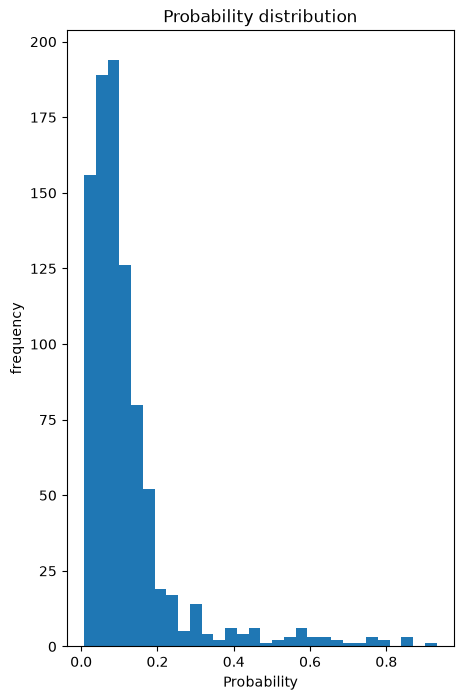

In [96]:
plt.figure(figsize=(5,8))
plt.hist(y_prob,bins=30)
plt.xlabel('Probability')
plt.ylabel('frequency')
plt.title('Probability distribution')

In [97]:
#tuned hyperparameter threshold for higher recall
y_predict_0_2=np.where(y_prob>=0.2,'yes','no')

In [98]:
new_cm=confusion_matrix(y_test,y_predict_0_2)

In [99]:
new_cm

array([[736,  65],
       [ 67,  37]])

In [100]:
#TN-736,FN-67,FP-65,TP-37

In [101]:
new_precision= precision_score(y_test,y_predict_0_2,pos_label='yes')
new_recall= recall_score(y_test,y_predict_0_2,pos_label='yes')

In [102]:
print('New Precision',new_precision)
print('New Recall' ,new_recall)

New Precision 0.3627450980392157
New Recall 0.3557692307692308


In [103]:
new_f1_score=f1_score(y_test,y_predict_0_2,pos_label='yes')

In [104]:
print('New F1 score',new_f1_score)

New F1 score 0.3592233009708738


In [105]:
f1_score_org=f1_score(y_test, y_pred, pos_label='yes')

In [106]:
f1_score

<function sklearn.metrics._classification.f1_score(y_true, y_pred, *, labels=None, pos_label=1, average='binary', sample_weight=None, zero_division='warn')>

In [107]:
thresholds=np.arange(0.1,0.9,0.01)

In [108]:
f1_scores={}
for threshold in thresholds:
    new_pred=np.where(y_prob>=threshold,'yes','no')
    temp_f1_score=f1_score(y_test,new_pred,pos_label='yes')
    f1_scores[threshold]=temp_f1_score

In [109]:
best_key, best_value = max(f1_scores.items(), key=lambda x: x[1])

print(f"Best threshold: {best_key}, Best f1: {best_value}")

Best threshold: 0.16999999999999998, Best f1: 0.376


<h3>Creating training data further from training data </h3>

In [110]:
X_train_model,X_val,y_train_model,y_val=train_test_split(
    X_train,y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

In [111]:
train_pipeline=pipeline.fit(X_train_model, y_train_model)
y_val_prob = pipeline.predict_proba(X_val)[:, 1]

In [112]:
new_f1_scores={}
for threshold in thresholds:
    new_pred=np.where(y_val_prob>=threshold,'yes','no')
    temp_f1_score=f1_score(y_val,new_pred,pos_label='yes')
    new_f1_scores[threshold]=temp_f1_score

In [113]:
new_best_key, new_best_value = max(new_f1_scores.items(), key=lambda x: x[1])

print(f"Best threshold: {new_best_key}, Best f1: {new_best_value}")

Best threshold: 0.20999999999999996, Best f1: 0.4430379746835443


In [114]:
y_test_prob = pipeline.predict_proba(X_test)[:, 1]

y_test_pred = np.where(y_test_prob >= 0.21, 'yes', 'no')

print(confusion_matrix(y_test, y_test_pred))
print(precision_score(y_test, y_test_pred, pos_label='yes'))
print(recall_score(y_test, y_test_pred, pos_label='yes'))
print(f1_score(y_test, y_test_pred, pos_label='yes'))

[[740  61]
 [ 69  35]]
0.3645833333333333
0.33653846153846156
0.35


In [115]:
roc_auc = roc_auc_score(y_test, y_test_prob)

In [116]:
roc_auc

0.734070392778258

<h2>Random forest 🌲🌲🌲</h2>

In [118]:
from sklearn.ensemble import RandomForestClassifier

In [119]:
random_forest_pipeline=Pipeline([
    ('preprocesser',preprocesser),
    ('model',RandomForestClassifier())
])

In [120]:
random_forest_pipeline.fit(X_train_model,y_train_model)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesser', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['no','yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['age','job','marital',...,'previous','poutcome', 'was_previously_contacted']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passth

In [121]:
rf_val_prob= random_forest_pipeline.predict_proba(X_val)[:,1]

In [122]:
rf_val_pred = np.where(rf_val_prob >= 0.5, 'yes', 'no')

In [123]:
rf_org_f1_score=f1_score(y_val,rf_val_pred,pos_label='yes')

In [124]:
rf_org_precision=precision_score(y_val,rf_val_pred,pos_label='yes')

In [125]:
rf_org_recall=recall_score(y_val,rf_val_pred,pos_label='yes')

In [126]:
print('F1 score at 0.5',rf_org_f1_score)
print('Recall score at 0.5',rf_org_recall)
print('Precesion score at 0.5',rf_org_precision)

F1 score at 0.5 0.2830188679245283
Recall score at 0.5 0.18072289156626506
Precesion score at 0.5 0.6521739130434783


In [127]:
#fine tuning threshold parameter of random forest model
rf_f1_scores={}
for threshold in thresholds:
    rf_new_pred=np.where(rf_val_prob>=threshold,'yes','no')
    rf_temp_f1_score=f1_score(y_val,rf_new_pred,pos_label='yes')
    rf_f1_scores[threshold]=rf_temp_f1_score

In [128]:
rf_best_key, rf_best_value = max(rf_f1_scores.items(), key=lambda x: x[1])

print(f"Best threshold: {rf_best_key}, Best f1: {rf_best_value}")

Best threshold: 0.2799999999999999, Best f1: 0.4624277456647399


In [132]:
rf_predict_test=random_forest_pipeline.predict_proba(X_test)[:,1]
rf_tuned_pred=np.where(rf_predict_test>=0.28,'yes','no')


In [133]:
print(confusion_matrix(y_test, rf_tuned_pred))
print(precision_score(y_test, rf_tuned_pred, pos_label='yes'))
print(recall_score(y_test, rf_tuned_pred, pos_label='yes'))
print(f1_score(y_test, rf_tuned_pred, pos_label='yes'))

[[732  69]
 [ 67  37]]
0.3490566037735849
0.3557692307692308
0.3523809523809524


In [134]:
roc_auc_score(y_test, rf_predict_test)

0.7223962834917892